[OUTPUT] Saving plots to: C:\Users\Lenovo\chronoslab_outputs
[DATA] Fetching 6500 × 1h bars for BTC/USDT ...
[DATA] Loaded 6500 rows | 2025-06-25 00:00:00+00:00 → 2026-03-22 19:00:00+00:00


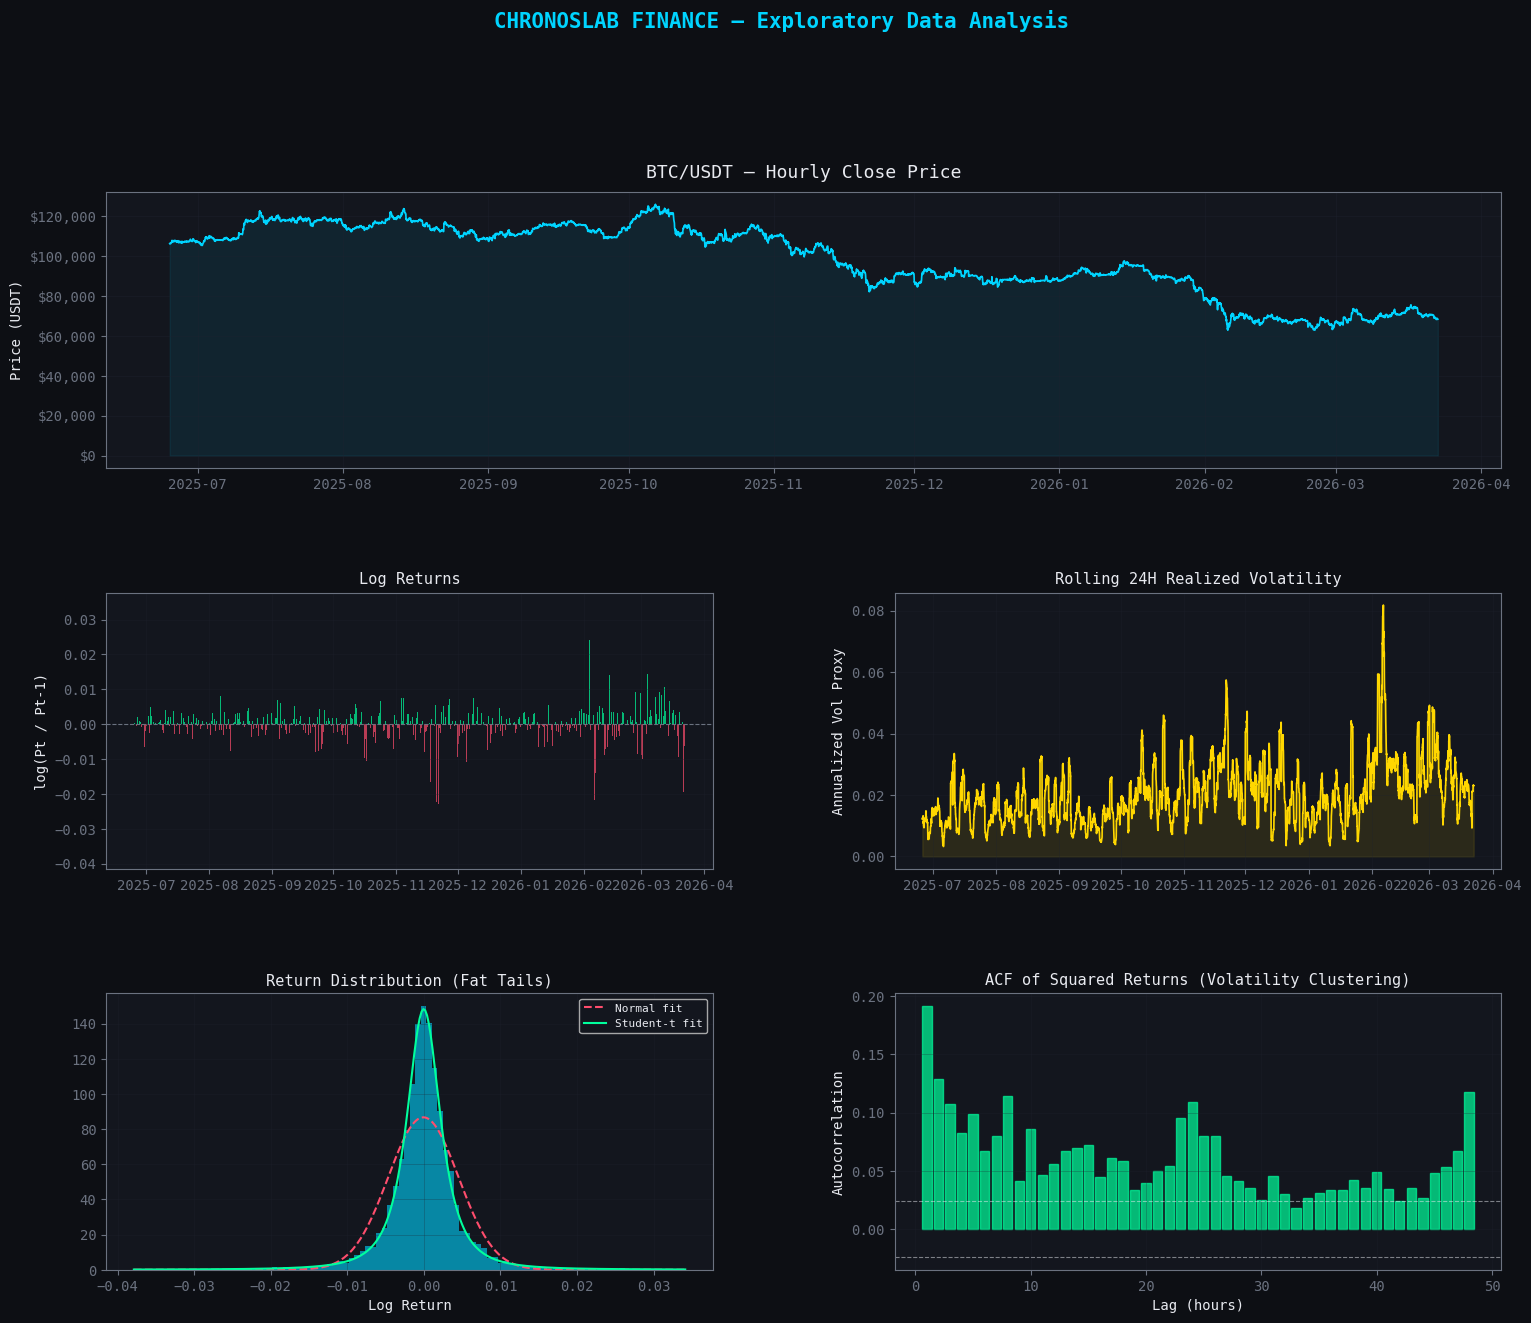

[PLOT] EDA saved.

[ADF TEST] Log Returns
   Statistic : -33.1195
   p-value   : 0.000000
   Stationary: YES ✓

  CHRONOSLAB FINANCE Option B | horizon=5H | train=6494
  Target: Vol-correction ratio  |  EVAL_WINDOW=400

[ETS] Fitting on 6494 points | seasonal_period=24
[ETS] In-sample residual std: 0.004595
[ETS] Test MSE on returns:    0.00000414

[GARCH] Fitting GARCH(1,1) | dist=studentst on 6494 residuals
[GARCH] AIC=5367.68 | BIC=5401.57
[GARCH] omega=0.00963 | alpha=0.2349 | beta=0.7651
[GARCH] Forecast vol (next 5h): mean=0.4903% | max=0.5098%

[STANDARDIZED z_t] mean=-0.0116 | std=1.0141 | kurtosis=11.8559


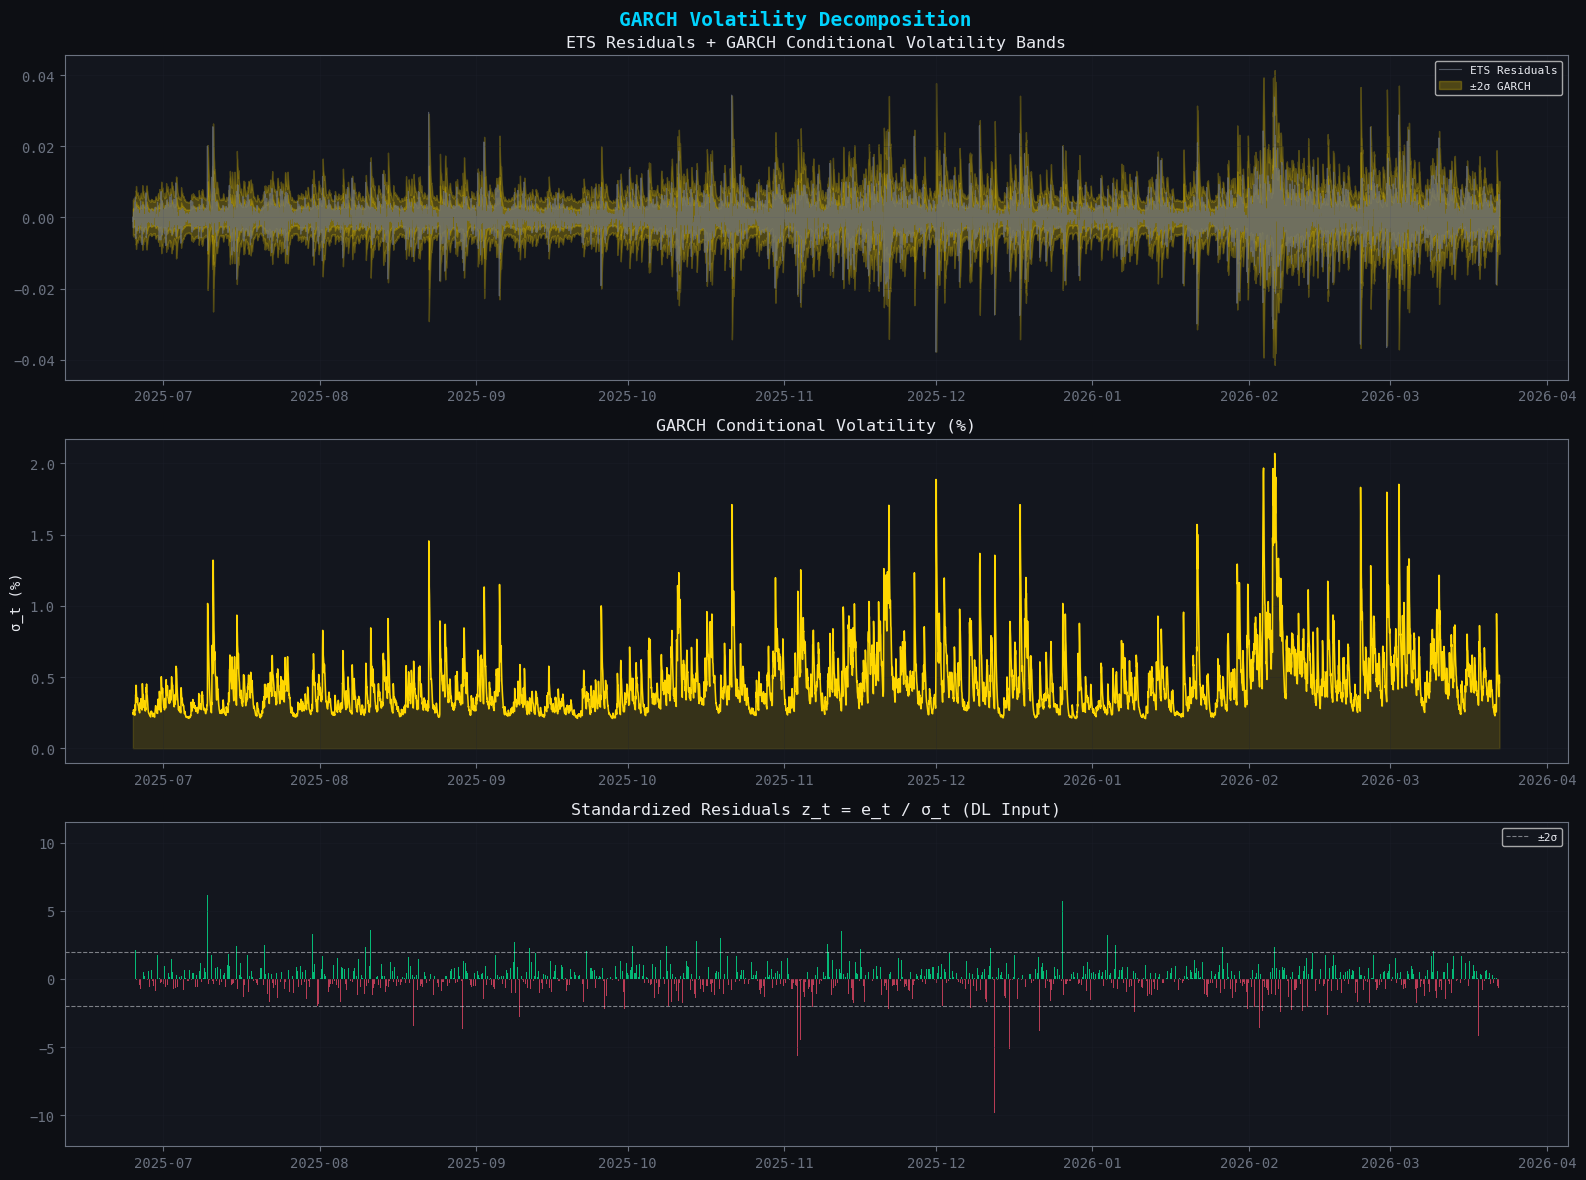

[PLOT] GARCH diagnostics saved.

[ALPHA GATE] Vol-ratio mean: 0.6862  std: 0.7466  (threshold std>0.1)
[ALPHA GATE] >>> TRIGGERED: DL Phase active ✓

   --- GBR VOL CORRECTOR (target=vol_ratio, H=5) ---
       GBR trained 5 models on 6065 sequences.
       GBR rolling vol-ratio corr: 0.2615  (n=2000)

   --- BiLSTM VOL CORRECTOR (target=vol_ratio, H=5) ---
       BiLSTM training on 6065 sequences...
       BiLSTM rolling vol-ratio corr: 0.2451  (n=2000)

[GATED BLEND]
   GBR  roll_corr=0.262  → α=0.157  (APPLIED ✓)
   LSTM roll_corr=0.245  → α=0.196  (APPLIED ✓)


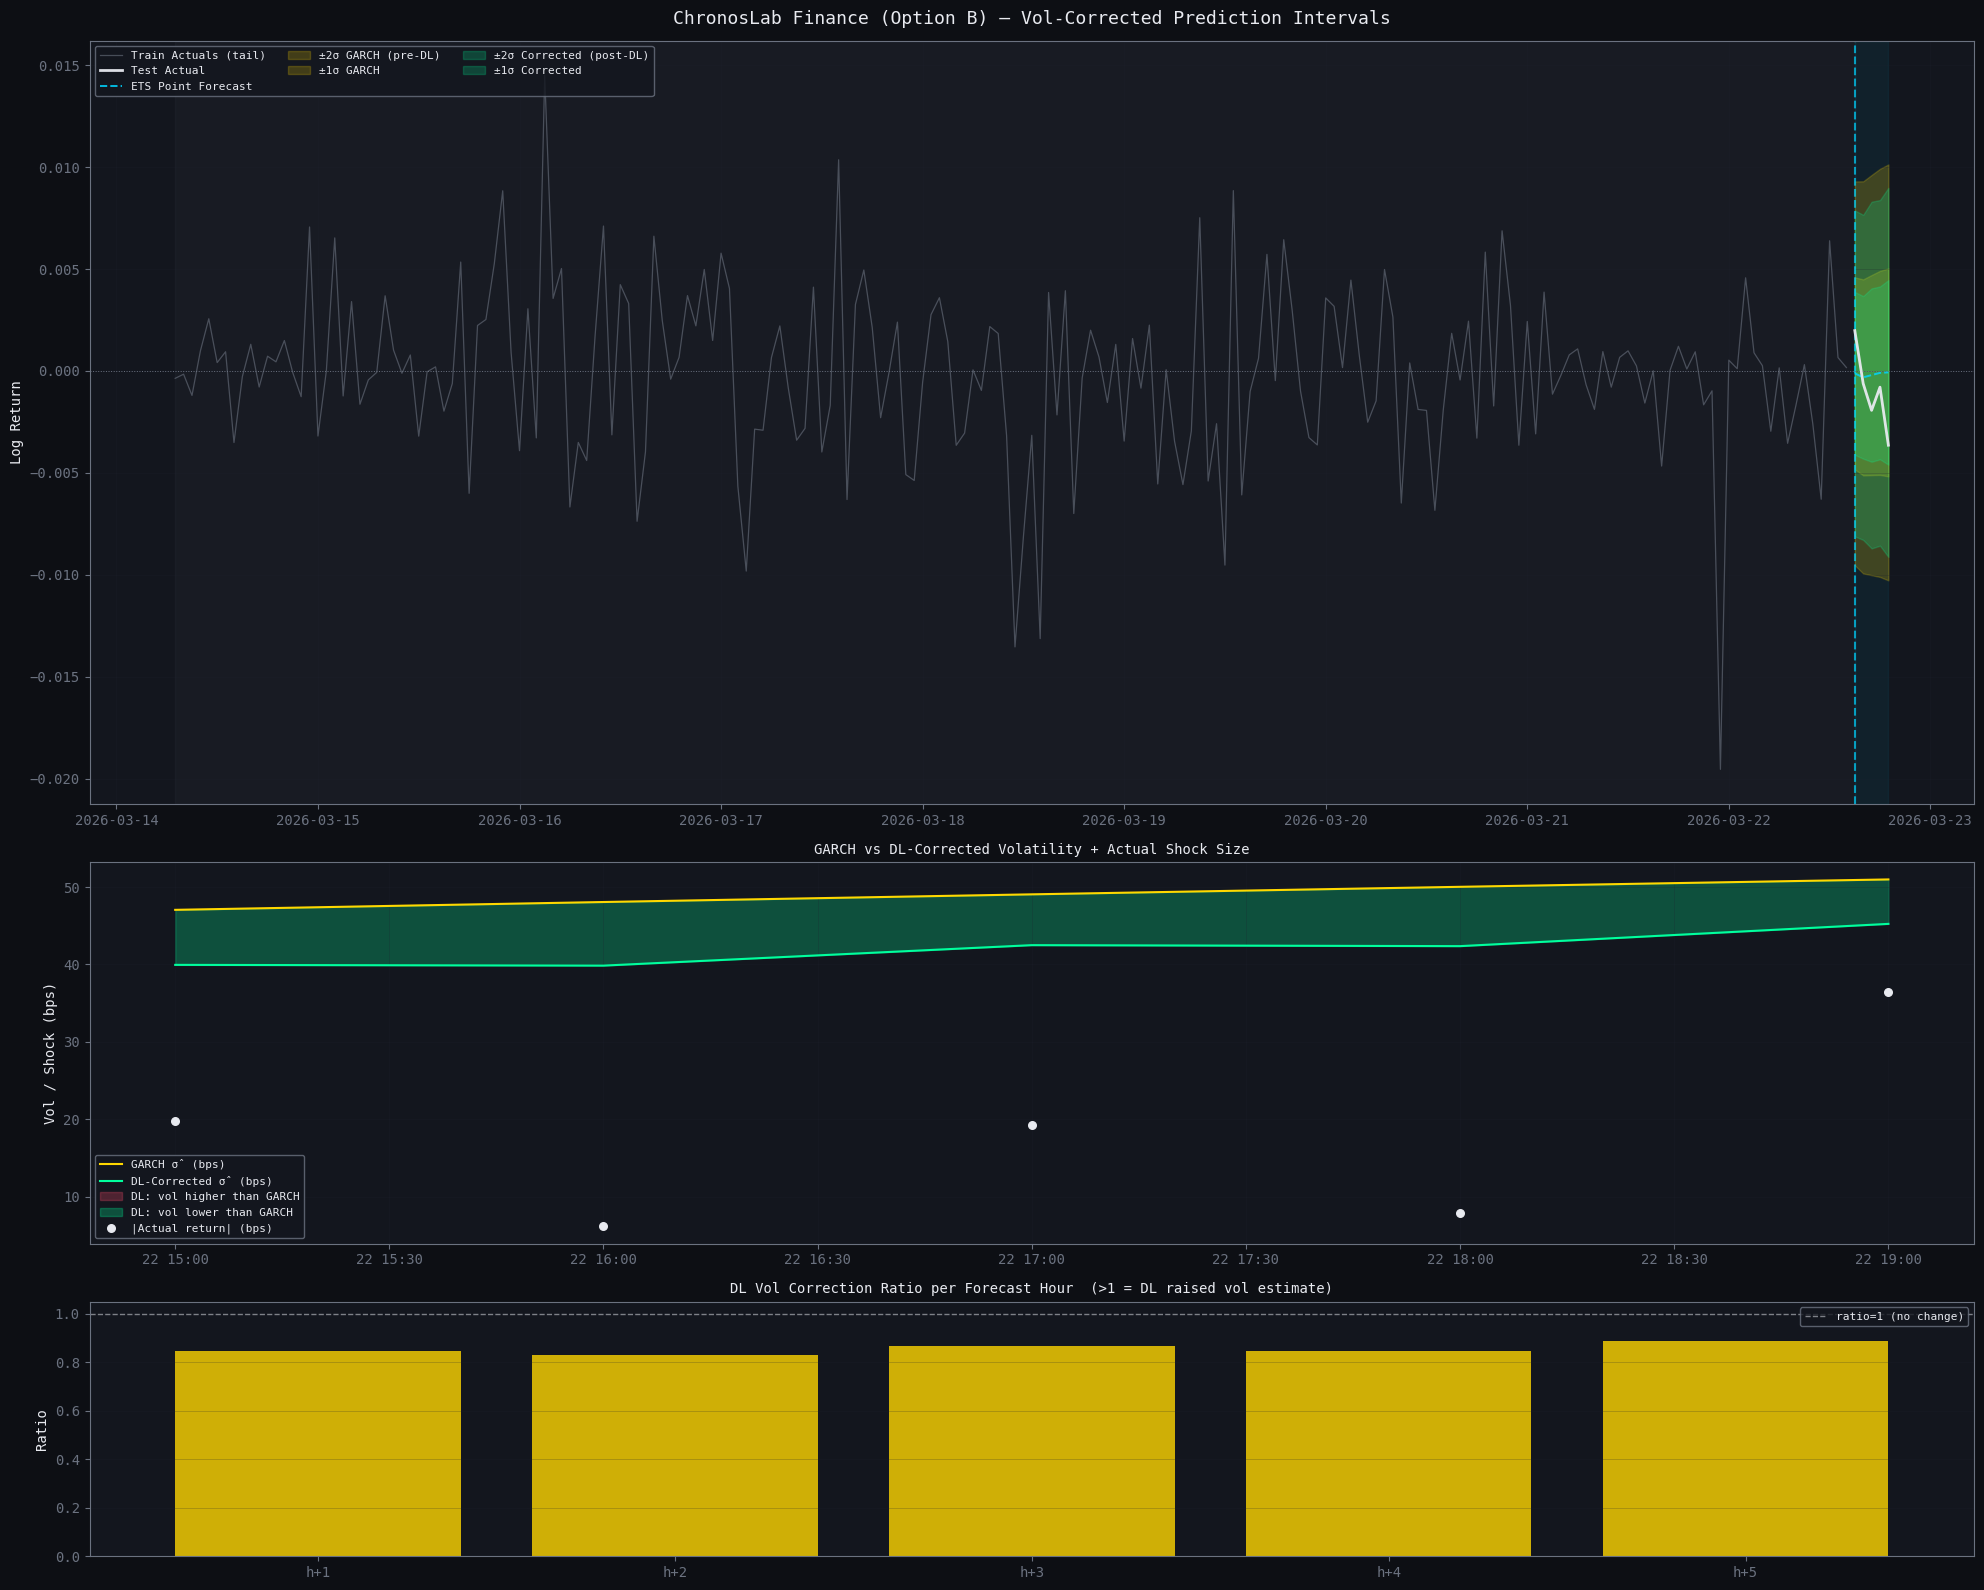

[PLOT] Vol forecast plot saved.


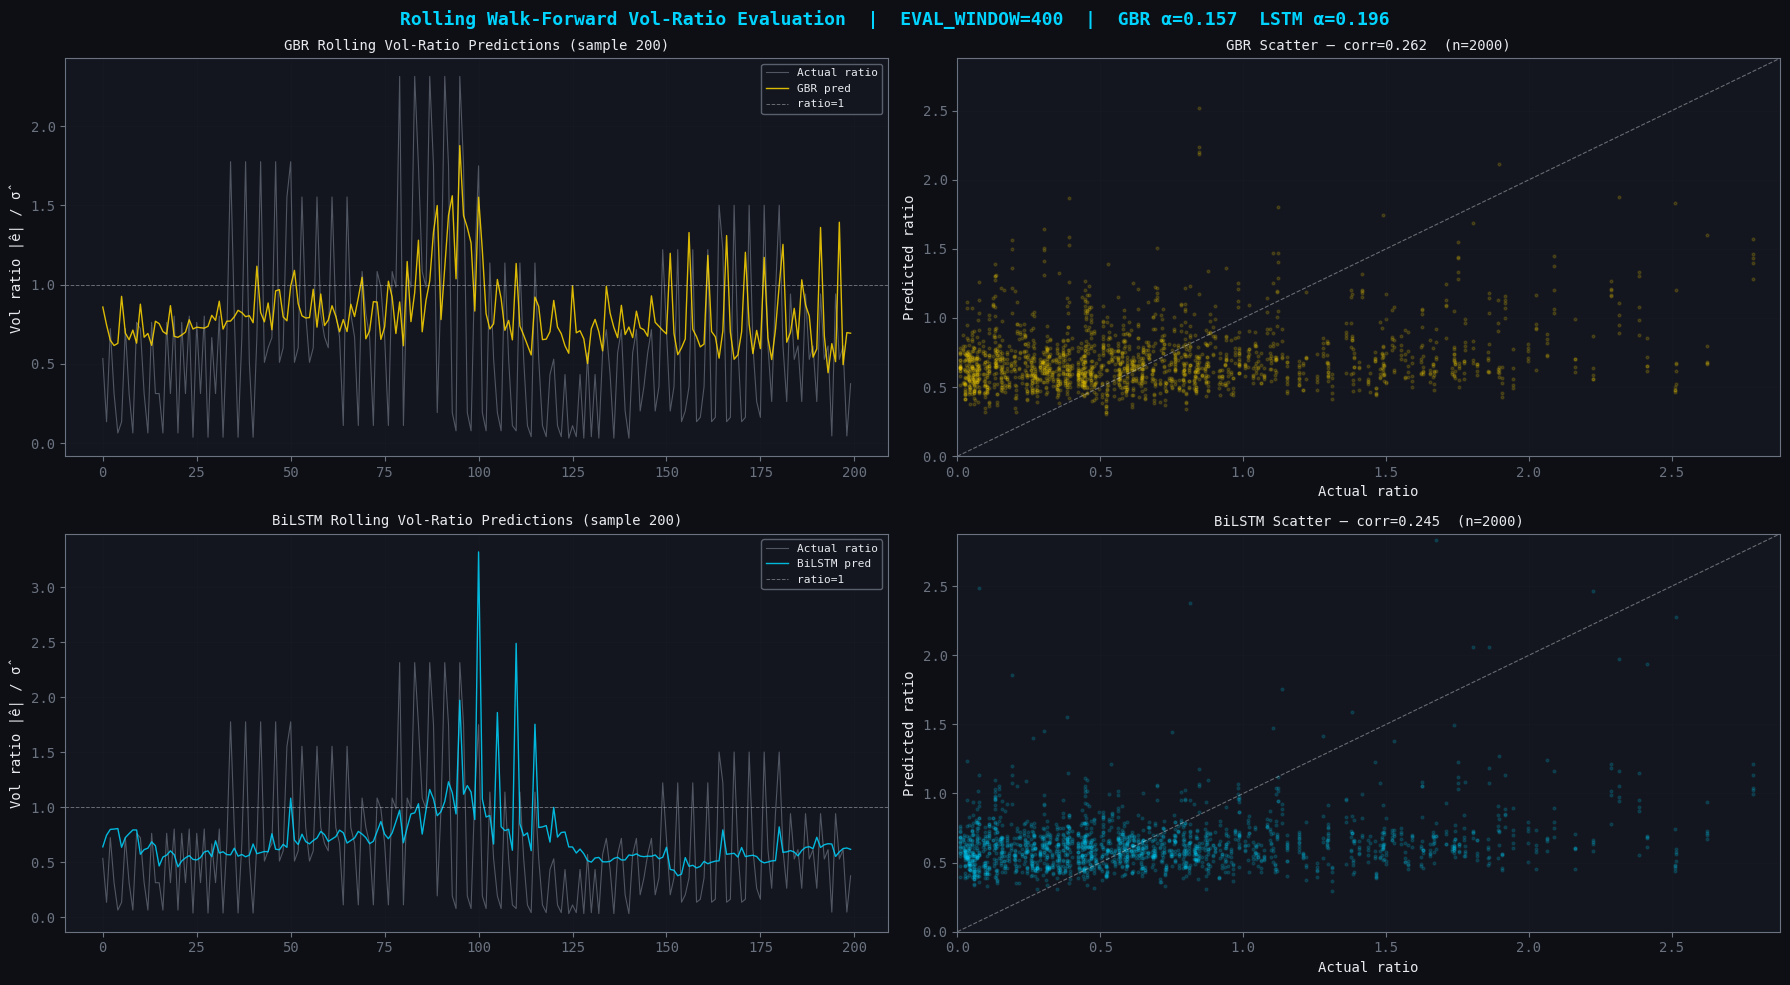

[PLOT] Rolling backtest plot saved.


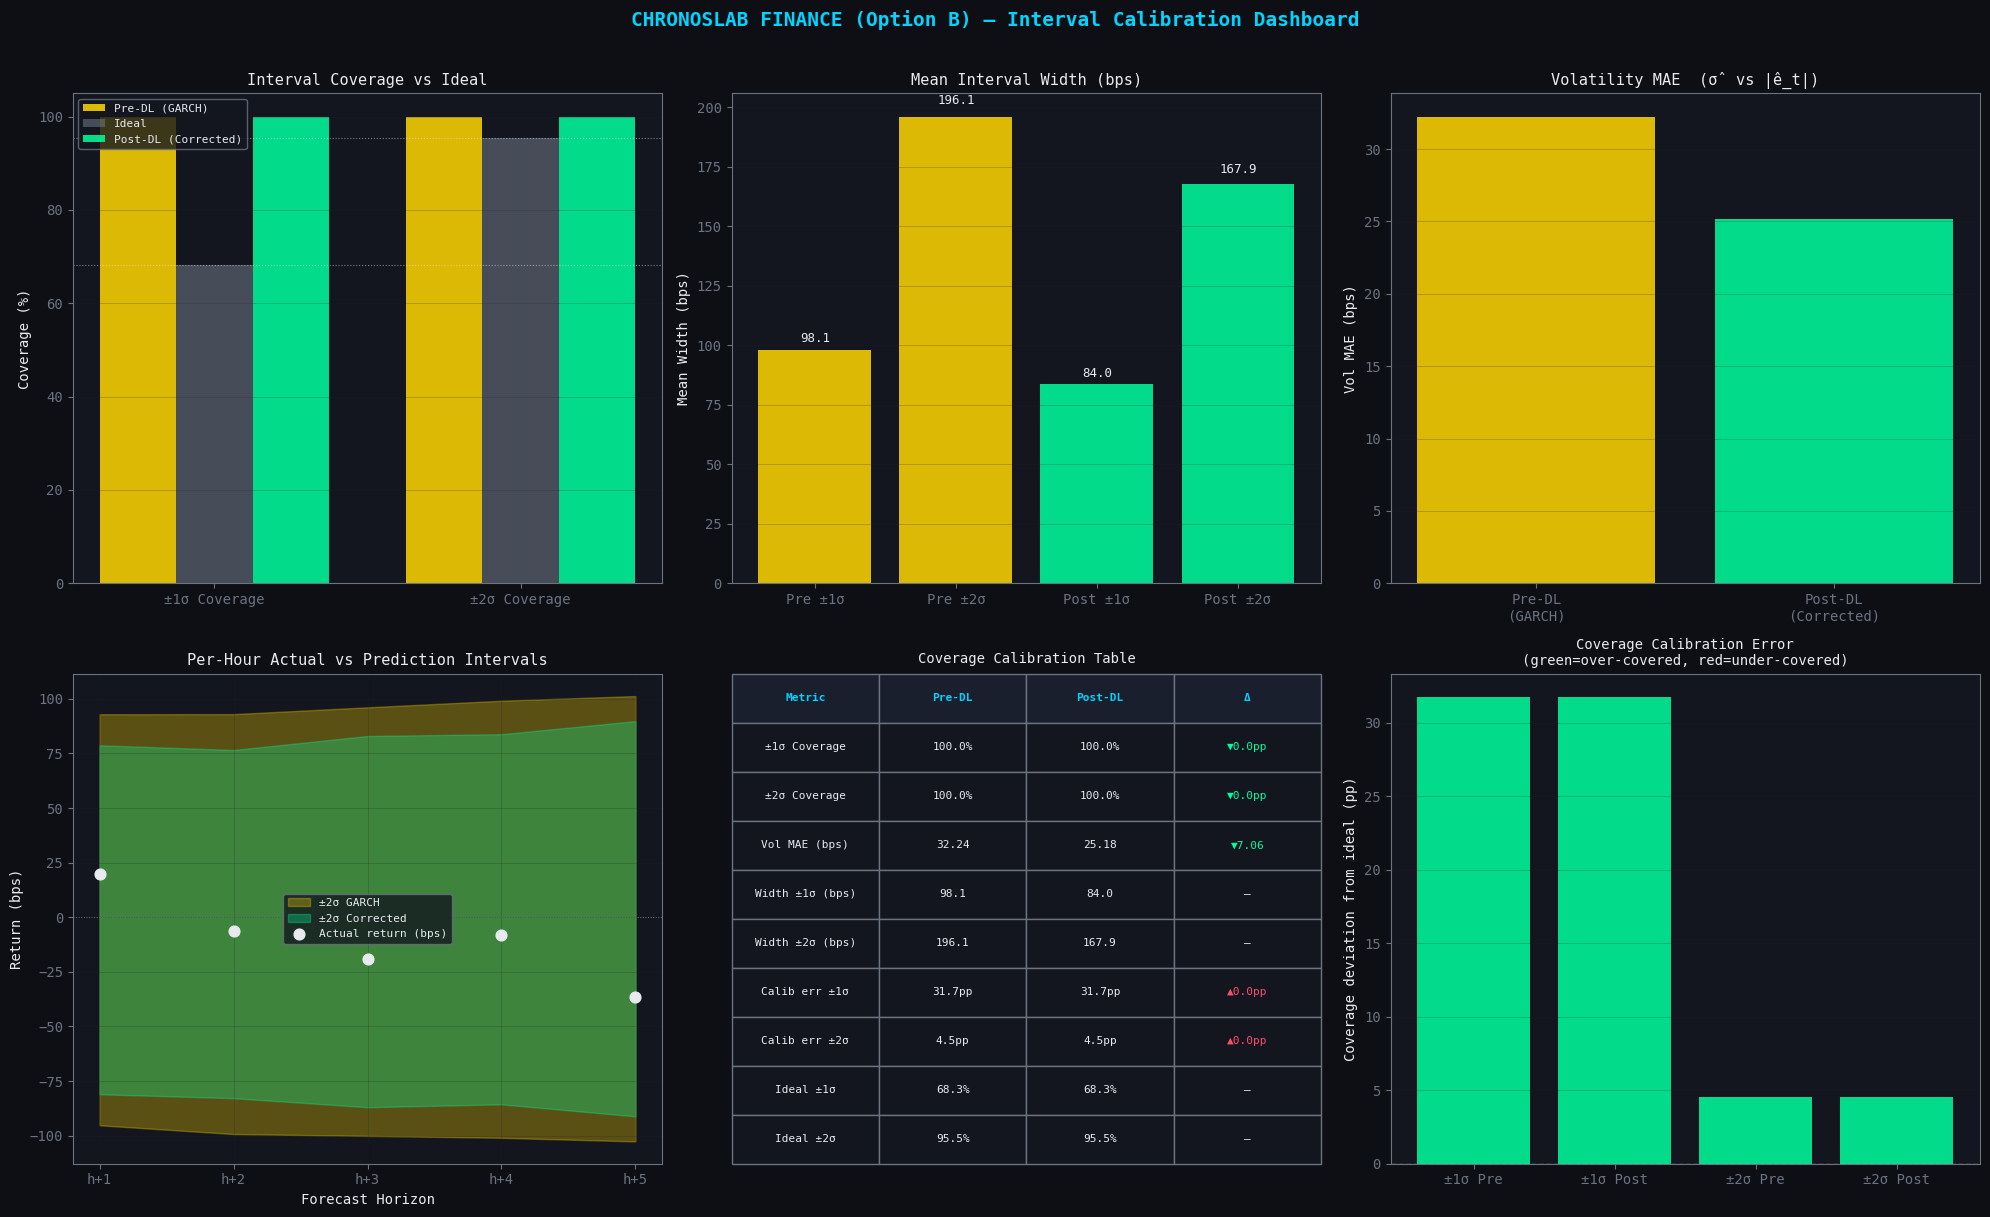

[PLOT] Coverage dashboard saved.

  CHRONOSLAB FINANCE (Option B) — VOL CORRECTION REPORT
  Status      : ✓ SUCCESS
  Hybrid Mode : True
  GBR   α=0.157  roll_corr=0.262
  LSTM  α=0.196  roll_corr=0.245
  ────────────────────────────────────────────────────────────
  INTERVAL CALIBRATION METRICS (n=5 test points)
  ────────────────────────────────────────────────────────────
  Metric                         Pre-DL        Post-DL    Ideal
  ────────────────────────────────────────────────────────────
  ±1σ Coverage (%)               100.00         100.00    68.27
  ±2σ Coverage (%)               100.00         100.00    95.45
  Vol MAE (bps)                   32.24          25.18        —
  Width ±2σ (bps)                196.14         167.91        —
  Calib err ±1σ (pp)              31.73          31.73     0.00
  Calib err ±2σ (pp)               4.55           4.55     0.00
  ────────────────────────────────────────────────────────────
  ROLLING VOL-RATIO EVAL (n=2000 pairs — statist

In [5]:
# ============================================================
# CHRONOSLAB FINANCE — Option A
# Architecture: ETS (mean) → GARCH (vol) → Dual-Gated DL
# Target: Standardized Residual Correction → Return Forecast
# Data:   BTC/USDT 1H via ccxt (Binance public API)
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.colors as mcolors

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from scipy import stats

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Input,
                                     Concatenate, Bidirectional)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

import ccxt
import time
import os
from pathlib import Path

tf.get_logger().setLevel('ERROR')

# ─────────────────────────────────────────────────────────────
# OUTPUT DIRECTORY — cross-platform (Windows / Mac / Linux)
# ─────────────────────────────────────────────────────────────
try:
    _base = Path(__file__).parent
except NameError:          # running inside a Jupyter notebook
    _base = Path.cwd()
OUT_DIR = _base / "chronoslab_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"[OUTPUT] Saving plots to: {OUT_DIR.resolve()}")

# ─────────────────────────────────────────────────────────────
# STYLE
# ─────────────────────────────────────────────────────────────
DARK   = "#0d0f14"
PANEL  = "#13161e"
ACCENT = "#00d4ff"
GREEN  = "#00ff9d"
RED    = "#ff4d6d"
GOLD   = "#ffd700"
MUTED  = "#6b7280"
WHITE  = "#e8eaf0"

plt.rcParams.update({
    "figure.facecolor":  DARK,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    MUTED,
    "axes.labelcolor":   WHITE,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "text.color":        WHITE,
    "grid.color":        "#1f2330",
    "grid.linewidth":    0.6,
    "font.family":       "monospace",
    "lines.linewidth":   1.4,
})

# ============================================================
# MODULE 0 — DATA ACQUISITION (ccxt / Binance public)
# ============================================================
def fetch_btc_ohlcv(symbol="BTC/USDT", timeframe="1h", n_candles=6500):
    print(f"[DATA] Fetching {n_candles} × {timeframe} bars for {symbol} ...")
    exchange = ccxt.binance({"enableRateLimit": True})
    
    all_ohlcv = []
    since     = exchange.milliseconds() - n_candles * 3600 * 1000  # approx 1h in ms
    limit     = 1000

    while len(all_ohlcv) < n_candles:
        batch = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=limit)
        if not batch:
            break
        all_ohlcv.extend(batch)
        since = batch[-1][0] + 1
        time.sleep(0.2)

    df = pd.DataFrame(all_ohlcv, columns=["timestamp","open","high","low","close","volume"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp").sort_index()
    df = df[~df.index.duplicated(keep="first")]
    df = df.tail(n_candles)
    print(f"[DATA] Loaded {len(df)} rows | {df.index[0]} → {df.index[-1]}")
    return df

# ============================================================
# MODULE 1 — PREPROCESSING & EDA PLOTS
# ============================================================
def compute_log_returns(df):
    df = df.copy()
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    df = df.dropna()
    return df

def plot_eda(df):
    fig = plt.figure(figsize=(18, 14), facecolor=DARK)
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

    # 1. Price
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df.index, df["close"], color=ACCENT, lw=1.2)
    ax1.fill_between(df.index, df["close"], alpha=0.08, color=ACCENT)
    ax1.set_title("BTC/USDT — Hourly Close Price", fontsize=13, color=WHITE, pad=10)
    ax1.set_ylabel("Price (USDT)")
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax1.grid(True, alpha=0.4)

    # 2. Log returns
    ax2 = fig.add_subplot(gs[1, 0])
    colors = [GREEN if r >= 0 else RED for r in df["log_return"]]
    ax2.bar(df.index, df["log_return"], color=colors, width=0.03, alpha=0.7)
    ax2.set_title("Log Returns", fontsize=11, color=WHITE)
    ax2.set_ylabel("log(Pt / Pt-1)")
    ax2.axhline(0, color=MUTED, lw=0.8, ls="--")
    ax2.grid(True, alpha=0.3)

    # 3. Rolling volatility
    ax3 = fig.add_subplot(gs[1, 1])
    roll_vol = df["log_return"].rolling(24).std() * np.sqrt(24)
    ax3.plot(df.index, roll_vol, color=GOLD, lw=1.2)
    ax3.fill_between(df.index, roll_vol, alpha=0.1, color=GOLD)
    ax3.set_title("Rolling 24H Realized Volatility", fontsize=11, color=WHITE)
    ax3.set_ylabel("Annualized Vol Proxy")
    ax3.grid(True, alpha=0.3)

    # 4. Return distribution
    ax4 = fig.add_subplot(gs[2, 0])
    ret = df["log_return"].dropna()
    ax4.hist(ret, bins=100, color=ACCENT, alpha=0.6, density=True, edgecolor="none")
    xr  = np.linspace(ret.min(), ret.max(), 300)
    ax4.plot(xr, stats.norm.pdf(xr, ret.mean(), ret.std()), color=RED, lw=1.5, ls="--", label="Normal fit")
    ax4.plot(xr, stats.t.pdf(xr, *stats.t.fit(ret)), color=GREEN, lw=1.5, label="Student-t fit")
    ax4.set_title("Return Distribution (Fat Tails)", fontsize=11, color=WHITE)
    ax4.set_xlabel("Log Return")
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    # 5. ACF of squared returns (vol clustering signal)
    ax5 = fig.add_subplot(gs[2, 1])
    sq_ret = ret**2
    lags   = 48
    acf_vals = [sq_ret.autocorr(lag=l) for l in range(1, lags+1)]
    bars = ax5.bar(range(1, lags+1), acf_vals, color=GOLD, alpha=0.7, width=0.8)
    for b, v in zip(bars, acf_vals):
        b.set_color(GREEN if v > 0 else RED)
    conf = 1.96 / np.sqrt(len(ret))
    ax5.axhline(conf,  color=WHITE, ls="--", lw=0.8, alpha=0.5)
    ax5.axhline(-conf, color=WHITE, ls="--", lw=0.8, alpha=0.5)
    ax5.set_title("ACF of Squared Returns (Volatility Clustering)", fontsize=11, color=WHITE)
    ax5.set_xlabel("Lag (hours)")
    ax5.set_ylabel("Autocorrelation")
    ax5.grid(True, alpha=0.3)

    fig.suptitle("CHRONOSLAB FINANCE — Exploratory Data Analysis", 
                 fontsize=15, color=ACCENT, fontweight="bold", y=1.01)
    plt.savefig(OUT_DIR / "eda.png", dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("[PLOT] EDA saved.")

def stationarity_report(series, name="Log Returns"):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\n[ADF TEST] {name}")
    print(f"   Statistic : {result[0]:.4f}")
    print(f"   p-value   : {result[1]:.6f}")
    print(f"   Stationary: {'YES ✓' if result[1] < 0.05 else 'NO ✗'}")

# ============================================================
# MODULE 2 — ETS MEAN MODEL
# ============================================================
def fit_ets_mean(train, period=24):
    model = ExponentialSmoothing(
        train, trend="add", damped_trend=True,
        seasonal="add", seasonal_periods=period
    ).fit(optimized=True)
    return model

def get_ets_forecast(train, test, period=24):
    print(f"\n[ETS] Fitting on {len(train)} points | seasonal_period={period}")
    model    = fit_ets_mean(train, period)
    forecast = pd.Series(model.forecast(len(test)), index=test.index)
    residuals = pd.Series(model.resid.values, index=train.index).fillna(0)
    
    ets_mse = mean_squared_error(test, forecast)
    print(f"[ETS] In-sample residual std: {residuals.std():.6f}")
    print(f"[ETS] Test MSE on returns:    {ets_mse:.8f}")
    return forecast, residuals

# ============================================================
# MODULE 3 — GARCH VOLATILITY MODEL
# ============================================================
def fit_garch(residuals, p=1, q=1, dist="studentst"):
    print(f"\n[GARCH] Fitting GARCH({p},{q}) | dist={dist} on {len(residuals)} residuals")
    # Scale to percentage returns for numerical stability
    scaled = residuals * 100
    am     = arch_model(scaled, vol="Garch", p=p, q=q, dist=dist, rescale=False)
    res    = am.fit(disp="off", show_warning=False)
    print(f"[GARCH] AIC={res.aic:.2f} | BIC={res.bic:.2f}")
    print(f"[GARCH] omega={res.params['omega']:.5f} | alpha={res.params['alpha[1]']:.4f} | beta={res.params['beta[1]']:.4f}")
    return res, scaled

def get_garch_volatility(garch_result, residuals_scaled, horizon):
    # In-sample conditional vol
    cond_vol_train = garch_result.conditional_volatility / 100  # back to original scale

    # Forecast vol for test horizon (rolling 1-step is most realistic)
    forecasts = garch_result.forecast(horizon=1, reindex=False)
    # For multi-step: use last in-sample vol as initial + decay
    last_var   = float(garch_result.conditional_volatility.iloc[-1]**2)
    omega      = float(garch_result.params["omega"])
    alpha      = float(garch_result.params["alpha[1]"])
    beta       = float(garch_result.params["beta[1]"])
    
    vols = []
    var_t = last_var
    for _ in range(horizon):
        var_t = omega + (alpha + beta) * var_t  # persistence equation
        vols.append(np.sqrt(var_t) / 100)       # back to original scale

    print(f"[GARCH] Forecast vol (next {horizon}h): mean={np.mean(vols)*100:.4f}% | max={np.max(vols)*100:.4f}%")
    return np.array(cond_vol_train), np.array(vols)

def compute_standardized_residuals(residuals, cond_vol_train):
    sigma = pd.Series(cond_vol_train, index=residuals.index)
    sigma = sigma.clip(lower=1e-8)
    z     = residuals / sigma
    print(f"\n[STANDARDIZED z_t] mean={z.mean():.4f} | std={z.std():.4f} | kurtosis={z.kurtosis():.4f}")
    return z

def plot_garch_diagnostics(residuals, cond_vol_train, z_t):
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), facecolor=DARK)

    # 1. Residuals + conditional vol bands
    ax = axes[0]
    ax.plot(residuals.index, residuals.values, color=MUTED, lw=0.8, alpha=0.7, label="ETS Residuals")
    sigma = pd.Series(cond_vol_train, index=residuals.index)
    ax.fill_between(residuals.index, -2*sigma, 2*sigma, alpha=0.25, color=GOLD, label="±2σ GARCH")
    ax.fill_between(residuals.index, -sigma,    sigma,   alpha=0.25, color=GOLD)
    ax.set_title("ETS Residuals + GARCH Conditional Volatility Bands", color=WHITE)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # 2. Conditional volatility
    ax = axes[1]
    ax.plot(residuals.index, sigma * 100, color=GOLD, lw=1.1)
    ax.fill_between(residuals.index, 0, sigma*100, alpha=0.15, color=GOLD)
    ax.set_title("GARCH Conditional Volatility (%)", color=WHITE)
    ax.set_ylabel("σ_t (%)")
    ax.grid(True, alpha=0.3)

    # 3. Standardized residuals z_t
    ax = axes[2]
    colors = [GREEN if v >= 0 else RED for v in z_t.values]
    ax.bar(z_t.index, z_t.values, color=colors, width=0.03, alpha=0.7)
    ax.axhline(2,  color=WHITE, ls="--", lw=0.8, alpha=0.5, label="±2σ")
    ax.axhline(-2, color=WHITE, ls="--", lw=0.8, alpha=0.5)
    ax.set_title("Standardized Residuals z_t = e_t / σ_t (DL Input)", color=WHITE)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    fig.suptitle("GARCH Volatility Decomposition", fontsize=14, color=ACCENT, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "garch_diagnostics.png", dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("[PLOT] GARCH diagnostics saved.")

# ============================================================
# MODULE 4 — FEATURE ENGINEERING
# Four feature groups, all strictly backward-looking (no leakage):
#   (A) Lagged residuals window
#   (B) Lagged GARCH vol window
#   (C) Regime context: realized vol, momentum, vol-ratio, vol-of-vol
#   (D) Time-of-day / day-of-week calendars
# ============================================================

def get_time_features(index):
    hour = index.hour
    dow  = index.dayofweek
    return np.column_stack([
        np.sin(2 * np.pi * hour / 24),
        np.cos(2 * np.pi * hour / 24),
        np.sin(2 * np.pi * dow  / 7),
        np.cos(2 * np.pi * dow  / 7),
        ((hour >= 8)  & (hour <= 10)).astype(float),   # Asia open
        ((hour >= 14) & (hour <= 16)).astype(float),   # EU/US overlap
        ((hour >= 20) & (hour <= 23)).astype(float),   # US close
        (dow >= 5).astype(float),                       # weekend
        hour.astype(float) / 23.0,
        dow.astype(float)  / 6.0,
    ])

def build_regime_features(returns_arr, garch_vol_arr):
    """
    7 regime context signals — all computed from past values only.

    returns_arr : raw log returns aligned with garch_vol_arr (train portion)
    garch_vol_arr: GARCH conditional vol (same length)

    Returns array of shape (N, 7).
    """
    ret = pd.Series(returns_arr)
    vol = pd.Series(garch_vol_arr)

    # Realized vol over past 24H and 48H — captures what GARCH may miss
    rvol_24 = ret.rolling(24, min_periods=1).std()
    rvol_48 = ret.rolling(48, min_periods=1).std()

    # Signed momentum: cumulative return over past 6H, 12H, 24H
    # Captures trending vs mean-reverting regimes
    mom_6  = ret.rolling(6,  min_periods=1).sum()
    mom_12 = ret.rolling(12, min_periods=1).sum()
    mom_24 = ret.rolling(24, min_periods=1).sum()

    # Vol ratio: current GARCH vol vs its 48H rolling mean
    # > 1 = elevated regime, < 1 = calm regime
    vol_mean_48 = vol.rolling(48, min_periods=1).mean().clip(lower=1e-8)
    vol_ratio   = (vol / vol_mean_48).fillna(1.0)

    # Vol-of-vol: rolling std of GARCH vol over 24H
    # High = GARCH itself is unstable (regime transition signal)
    vol_of_vol = vol.rolling(24, min_periods=1).std().fillna(0)

    return np.column_stack([
        rvol_24.values,
        rvol_48.values,
        mom_6.values,
        mom_12.values,
        mom_24.values,
        vol_ratio.values,
        vol_of_vol.values,
    ])  # shape (N, 7)

N_REGIME = 7    # regime context features
N_TIME   = 10   # time-of-day features
EVAL_WINDOW = 400  # rolling evaluation origins

# ============================================================
# MODULE 5 — DUAL GATE
# OPTION B: targets are vol correction ratios, not return residuals.
# Gate 1: does GARCH leave systematic over/underestimation?
#         Check variance of (|ê_t| / σ̂_t) — if high, DL can help.
# Gate 2: corr(predicted_ratio, actual_ratio) on rolling eval.
# ============================================================
def check_alpha_breakout(vol_ratios, alpha_thresh=0.10):
    """
    Gate 1 on vol ratios = |ê_t| / σ̂_t.
    If std(vol_ratio) is high the ratios are volatile and predictable.
    If std is low GARCH is already perfect — DL not needed.
    threshold=0.10 means >10% std in the ratio series triggers DL.
    """
    ratio_std  = float(np.std(vol_ratios))
    ratio_mean = float(np.mean(vol_ratios))
    print(f"\n[ALPHA GATE] Vol-ratio mean: {ratio_mean:.4f}  std: {ratio_std:.4f}  (threshold std>{alpha_thresh})")
    triggered = ratio_std > alpha_thresh
    print(f"[ALPHA GATE] >>> {'TRIGGERED: DL Phase active ✓' if triggered else 'NOT triggered. GARCH sufficient.'}")
    return triggered

def gated_alpha(val_preds, val_actual, base_alpha=0.40, min_corr=0.03):
    """Gate 2: correlation on rolling vol-ratio predictions vs actuals."""
    n = min(len(val_preds), len(val_actual))
    if n < 3:
        return 0.0, 0.0
    corr = np.corrcoef(val_actual[:n], val_preds[:n])[0, 1]
    if np.isnan(corr) or corr <= min_corr:
        return 0.0, float(corr) if not np.isnan(corr) else 0.0
    alpha = float(np.clip(base_alpha * corr, 0.03, base_alpha))
    return alpha, float(corr)

# ============================================================
# MODULE 6A — GBR CORRECTOR
#
# TARGET: vol_ratio_{t,k} = |ê_{t+k}| / σ̂_t  for k=1..H
#   One GBR model per forecast step.
#   Predicts how much GARCH under/overestimates at each future hour.
#
# FEATURES: lagged vol ratios + regime context + time
# ============================================================
def compute_vol_ratios(res_arr_raw, cond_vol):
    """
    Compute per-step vol ratios in original (unscaled) space.
    res_arr_raw: array of ETS residuals
    cond_vol:    array of GARCH conditional vol (same length)
    Returns: |ê_t| / σ̂_t  clipped to [0.01, 20] to prevent outlier explosion
    """
    ratios = np.abs(res_arr_raw) / np.clip(cond_vol, 1e-8, None)
    return np.clip(ratios, 0.01, 20.0)

def build_vol_features(ratio_arr, vol_arr, regime_arr, tf_arr, window_size):
    """Features for vol ratio prediction — lagged ratios as primary signal."""
    X = []
    for i in range(window_size, len(ratio_arr)):
        lag   = ratio_arr[i - window_size:i]
        stats = [np.mean(lag), np.std(lag), np.min(lag),
                 np.max(lag), np.median(lag), lag[-1], lag[-2], lag[-3]]
        row   = np.concatenate([lag, stats, [vol_arr[i]], regime_arr[i], tf_arr[i]])
        X.append(row)
    return np.array(X)

def execute_gbr_corrector(ets_residuals, returns_train, cond_vol_train,
                          garch_vol_test, horizon, test_index, window_size=24):
    print(f"\n   --- GBR VOL CORRECTOR (target=vol_ratio, H={horizon}) ---")
    full_idx = ets_residuals.index.append(test_index)
    tf_arr   = get_time_features(full_idx)

    # Vol ratios (unscaled — ratio is naturally interpretable)
    ratio_train = compute_vol_ratios(ets_residuals.values, cond_vol_train)

    # Scale ratio and vol for model inputs
    ratio_sc = RobustScaler()
    vol_sc   = RobustScaler()
    reg_sc   = RobustScaler()

    ratio_arr = ratio_sc.fit_transform(ratio_train.reshape(-1, 1)).flatten()
    vol_arr   = vol_sc.fit_transform(cond_vol_train.reshape(-1, 1)).flatten()
    regime_raw = build_regime_features(returns_train, cond_vol_train)
    regime_arr = reg_sc.fit_transform(regime_raw)

    train_end = len(ratio_arr) - EVAL_WINDOW - horizon
    if train_end < window_size + horizon:
        train_end = len(ratio_arr) - horizon - 10

    # Build X and y together in one consistent loop — avoids any index mismatch
    X_all_list, ys = [], [[] for _ in range(horizon)]
    valid_idxs = []
    for i in range(window_size, len(ratio_arr)):
        if i + horizon >= len(ratio_train):
            continue
        lag   = ratio_arr[i - window_size:i]
        stats = [np.mean(lag), np.std(lag), np.min(lag),
                 np.max(lag), np.median(lag), lag[-1], lag[-2], lag[-3]]
        row   = np.concatenate([lag, stats, [vol_arr[i]], regime_arr[i], tf_arr[i]])
        X_all_list.append(row)
        valid_idxs.append(i)
        for k in range(horizon):
            ys[k].append(ratio_train[i + k])

    X_all       = np.array(X_all_list)
    valid_idxs  = np.array(valid_idxs)
    train_mask  = valid_idxs < train_end
    X_tr        = X_all[train_mask]

    gbr_models = []
    for k in range(horizon):
        y_k = np.array(ys[k])
        gbr = GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.03, max_depth=4,
            min_samples_leaf=5, subsample=0.8, random_state=42 + k)
        gbr.fit(X_tr, y_k[train_mask])
        gbr_models.append(gbr)
    print(f"       GBR trained {horizon} models on {X_tr.shape[0]} sequences.")

    # ── ROLLING WALK-FORWARD EVALUATION on vol ratios
    all_val_preds, all_val_actual = [], []
    eval_end = min(train_end + EVAL_WINDOW, len(ratio_arr) - horizon)

    # Use valid_idxs to find evaluation rows cleanly
    eval_mask = (valid_idxs >= train_end) & (valid_idxs < eval_end)
    X_eval    = X_all[eval_mask]
    idxs_eval = valid_idxs[eval_mask]

    for row_idx, i in enumerate(idxs_eval):
        row = X_eval[row_idx]
        for k, gbr in enumerate(gbr_models):
            pred   = gbr.predict([row])[0]
            actual = ratio_train[i + k]
            all_val_preds.append(pred)
            all_val_actual.append(actual)

    val_preds  = np.array(all_val_preds)
    val_actual = np.array(all_val_actual)
    n_eval     = len(val_preds)
    corr_val   = float(np.corrcoef(val_actual, val_preds)[0, 1]) if n_eval > 2 else 0.0
    print(f"       GBR rolling vol-ratio corr: {corr_val:.4f}  (n={n_eval})")

    # ── LIVE TEST: predict vol correction ratios for next H hours
    # Use the last row in X_all (corresponds to the most recent window)
    test_row    = X_all[-1]
    test_ratios = np.array([gbr_models[k].predict([test_row])[0] for k in range(horizon)])

    return test_ratios, val_preds, val_actual

# ============================================================
# MODULE 6B — BiLSTM VOL CORRECTOR
# Dense(H) output — one vol ratio per future hour.
# ============================================================
def build_bilstm_vol(window_size, n_static, horizon):
    """
    Sequence: [ratio_t, σ̂_t] over window_size steps
    Static:   regime + time features
    Output:   H vol correction ratios
    """
    seq_in = Input(shape=(window_size, 2), name="seq")
    x = Bidirectional(LSTM(64, activation="tanh", return_sequences=True,
                           kernel_regularizer=regularizers.l2(0.005)))(seq_in)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(32, activation="tanh",
                           kernel_regularizer=regularizers.l2(0.005)))(x)
    x = Dropout(0.2)(x)

    static_in = Input(shape=(n_static,), name="static")
    s = Dense(32, activation="relu")(static_in)
    s = Dense(16, activation="relu")(s)

    m   = Concatenate()([x, s])
    m   = Dense(64, activation="relu")(m)
    m   = Dropout(0.1)(m)
    # Softplus output: ratios must be positive
    out = Dense(horizon, activation="softplus")(m)
    model = Model([seq_in, static_in], out)
    model.compile(optimizer=Adam(0.001), loss="huber")
    return model

def execute_lstm_corrector(ets_residuals, returns_train, cond_vol_train,
                           garch_vol_test, horizon, test_index,
                           window_size=24, epochs=100):
    print(f"\n   --- BiLSTM VOL CORRECTOR (target=vol_ratio, H={horizon}) ---")
    full_idx = ets_residuals.index.append(test_index)
    tf_arr   = get_time_features(full_idx)

    ratio_train = compute_vol_ratios(ets_residuals.values, cond_vol_train)

    ratio_sc = RobustScaler()
    vol_sc   = RobustScaler()
    reg_sc   = RobustScaler()

    ratio_arr  = ratio_sc.fit_transform(ratio_train.reshape(-1, 1)).flatten()
    vol_arr    = vol_sc.fit_transform(cond_vol_train.reshape(-1, 1)).flatten()
    regime_raw = build_regime_features(returns_train, cond_vol_train)
    regime_arr = reg_sc.fit_transform(regime_raw)

    n_static  = N_REGIME + N_TIME
    train_end = len(ratio_arr) - EVAL_WINDOW - horizon
    if train_end < window_size + horizon:
        train_end = len(ratio_arr) - horizon - 10

    # Training dataset
    X_seq, X_static, y_ms = [], [], []
    for i in range(window_size, train_end):
        if i + horizon >= len(ratio_train): continue
        seq    = np.column_stack([ratio_arr[i-window_size:i],
                                   vol_arr[i-window_size:i]])
        static = np.concatenate([regime_arr[i], tf_arr[i]])
        # Target: unscaled ratios for interpretability
        target = ratio_train[i:i+horizon]
        X_seq.append(seq); X_static.append(static); y_ms.append(target)

    X_seq    = np.array(X_seq)
    X_static = np.array(X_static)
    y_ms     = np.array(y_ms)   # (N, H) — actual vol ratios

    print(f"       BiLSTM training on {len(X_seq)} sequences...")
    lstm = build_bilstm_vol(window_size, n_static, horizon)
    vn   = max(1, int(len(X_seq) * 0.1))
    es   = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=0)
    rl   = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5, verbose=0)
    lstm.fit([X_seq[:-vn], X_static[:-vn]], y_ms[:-vn],
             validation_data=([X_seq[-vn:], X_static[-vn:]], y_ms[-vn:]),
             epochs=epochs, batch_size=32, verbose=0, callbacks=[es, rl])

    # ── ROLLING WALK-FORWARD EVALUATION
    all_val_preds, all_val_actual = [], []
    eval_end = min(train_end + EVAL_WINDOW, len(ratio_arr) - horizon)

    for i in range(train_end, eval_end):
        if i < window_size or i + horizon >= len(ratio_train): continue
        seq    = np.column_stack([ratio_arr[i-window_size:i],
                                   vol_arr[i-window_size:i]]).reshape(1, window_size, 2)
        static = np.concatenate([regime_arr[i], tf_arr[i]]).reshape(1, -1)
        preds  = lstm.predict([seq, static], verbose=0)[0]  # (H,) ratios
        for k in range(horizon):
            all_val_preds.append(float(preds[k]))
            all_val_actual.append(float(ratio_train[i + k]))

    val_preds  = np.array(all_val_preds)
    val_actual = np.array(all_val_actual)
    n_eval     = len(val_preds)
    corr_val   = float(np.corrcoef(val_actual, val_preds)[0, 1]) if n_eval > 2 else 0.0
    print(f"       BiLSTM rolling vol-ratio corr: {corr_val:.4f}  (n={n_eval})")

    # ── LIVE TEST
    seq    = np.column_stack([ratio_arr[-window_size:],
                               vol_arr[-window_size:]]).reshape(1, window_size, 2)
    static = np.concatenate([regime_arr[-1], tf_arr[len(ets_residuals)]]).reshape(1, -1)
    test_ratios = lstm.predict([seq, static], verbose=0)[0]

    return np.array(test_ratios), val_preds, val_actual

# ============================================================
# MODULE 7 — RECONSTRUCTION  (Option B)
#
# Point forecast:  r̂_t = ETS_t  (unchanged — not what we're improving)
# Corrected vol:   σ̂_corrected_k = σ̂_garch_k × DL_ratio_k
# Prediction band: r̂_t ± 2 × σ̂_corrected_t
#
# The DL component improves INTERVAL QUALITY, not point accuracy.
# Metrics: interval coverage, interval width, vol MAE.
# ============================================================
def reconstruct_vol(garch_vol_test, dl_ratio, test_index, alpha_gbr, alpha_lstm,
                    gbr_ratios, lstm_ratios):
    """
    Blend DL vol correction with GARCH baseline.
    corrected_sigma = garch_sigma × blended_ratio
    blended_ratio   = (1 - alpha_total) × 1.0 + alpha_gbr×gbr_r + alpha_lstm×lstm_r
    When both blocked (alpha=0), ratio=1 → corrected = garch (no change).
    """
    alpha_total = alpha_gbr + alpha_lstm
    if alpha_total > 0:
        blend_ratio = ((1 - alpha_total) * np.ones(len(garch_vol_test))
                       + alpha_gbr  * gbr_ratios
                       + alpha_lstm * lstm_ratios)
    else:
        blend_ratio = np.ones(len(garch_vol_test))

    blend_ratio  = np.clip(blend_ratio, 0.1, 5.0)   # safety clip
    corrected_sigma = garch_vol_test * blend_ratio
    return pd.Series(corrected_sigma, index=test_index), pd.Series(blend_ratio, index=test_index)

# ============================================================
# MODULE 8 — METRICS ENGINE  (Option B — vol-focused)
# ============================================================
def compute_coverage_metrics(actual_returns, ets_forecast, sigma_series, label=""):
    """
    Interval quality metrics:
    - Coverage at ±1σ (expect ~68%), ±2σ (expect ~95%)
    - Mean interval width (smaller is better if coverage holds)
    - Vol MAE: mean|σ̂_corrected - |ê_t||  (how well vol is calibrated)
    """
    actual  = np.array(actual_returns)
    center  = np.array(ets_forecast)
    sigma   = np.array(sigma_series)

    errors  = actual - center
    abs_err = np.abs(errors)

    cov_1sigma = np.mean(abs_err <= sigma)     * 100
    cov_2sigma = np.mean(abs_err <= 2 * sigma) * 100
    mean_width_1 = np.mean(2 * sigma)          * 1e4  # bps
    mean_width_2 = np.mean(4 * sigma)          * 1e4  # bps

    # Vol MAE: how close is σ̂ to actual shock size
    vol_mae = np.mean(np.abs(sigma - abs_err)) * 1e4   # bps

    # Calibration score: penalise deviation from ideal coverage
    calib_1 = abs(cov_1sigma - 68.27)
    calib_2 = abs(cov_2sigma - 95.45)

    return {
        "label":       label,
        "cov_1sig":    cov_1sigma,
        "cov_2sig":    cov_2sigma,
        "width_1sig":  mean_width_1,
        "width_2sig":  mean_width_2,
        "vol_mae_bps": vol_mae,
        "calib_err_1": calib_1,
        "calib_err_2": calib_2,
    }

def compute_rolling_vol_metrics(val_preds, val_actual, label=""):
    """Correlation + MAE for vol-ratio predictions on rolling eval."""
    n    = min(len(val_preds), len(val_actual))
    corr = float(np.corrcoef(val_actual[:n], val_preds[:n])[0, 1]) if n > 2 else 0.0
    mae  = float(np.mean(np.abs(val_actual[:n] - val_preds[:n])))
    bias = float(np.mean(val_preds[:n] - val_actual[:n]))
    return {"label": label, "corr": corr, "mae": mae, "bias": bias, "n": n}

# ============================================================
# MODULE 9 — PLOTS
# ============================================================
def plot_vol_forecast(train_r, test_r, ets_forecast,
                      garch_sigma, corrected_sigma, blend_ratio, tail_train=200):
    """
    Main results plot for Option B.
    Shows: actual returns, ETS forecast, GARCH band vs corrected band.
    """
    fig, axes = plt.subplots(3, 1, figsize=(20, 16), facecolor=DARK,
                             gridspec_kw={"height_ratios": [3, 1.5, 1]})

    train_tail = train_r.iloc[-tail_train:]
    split_time = test_r.index[0]

    # ── Panel 1: Returns + prediction intervals
    ax = axes[0]
    ax.axvspan(train_tail.index[0], split_time, alpha=0.06, color=MUTED)
    ax.axvspan(split_time, test_r.index[-1],    alpha=0.06, color=ACCENT)
    ax.axvline(split_time, color=ACCENT, lw=1.5, ls="--", alpha=0.7)

    ax.plot(train_tail.index, train_tail.values,
            color=MUTED, lw=0.9, alpha=0.6, label="Train Actuals (tail)")
    ax.plot(test_r.index, test_r.values,
            color=WHITE, lw=2.0, alpha=0.95, label="Test Actual", zorder=6)
    ax.plot(test_r.index, ets_forecast.values,
            color=ACCENT, lw=1.4, ls="--", alpha=0.85, label="ETS Point Forecast", zorder=5)

    # GARCH interval (pre-DL)
    ax.fill_between(test_r.index,
                    ets_forecast - 2*garch_sigma,
                    ets_forecast + 2*garch_sigma,
                    alpha=0.20, color=GOLD, label="±2σ GARCH (pre-DL)")
    ax.fill_between(test_r.index,
                    ets_forecast - garch_sigma,
                    ets_forecast + garch_sigma,
                    alpha=0.20, color=GOLD, label="±1σ GARCH")

    # Corrected interval (post-DL)
    ax.fill_between(test_r.index,
                    ets_forecast - 2*corrected_sigma,
                    ets_forecast + 2*corrected_sigma,
                    alpha=0.20, color=GREEN, label="±2σ Corrected (post-DL)")
    ax.fill_between(test_r.index,
                    ets_forecast - corrected_sigma,
                    ets_forecast + corrected_sigma,
                    alpha=0.20, color=GREEN, label="±1σ Corrected")

    ax.axhline(0, color=MUTED, lw=0.7, ls=":")
    ax.set_title("ChronosLab Finance (Option B) — Vol-Corrected Prediction Intervals",
                 color=WHITE, fontsize=13, pad=12)
    ax.set_ylabel("Log Return")
    ax.legend(fontsize=8, loc="upper left", ncol=3,
              facecolor=PANEL, edgecolor=MUTED, labelcolor=WHITE)
    ax.grid(True, alpha=0.25)

    # ── Panel 2: GARCH vol vs corrected vol
    ax2 = axes[1]
    ax2.plot(test_r.index, garch_sigma.values    * 1e4, color=GOLD,  lw=1.5,
             label="GARCH σ̂ (bps)")
    ax2.plot(test_r.index, corrected_sigma.values * 1e4, color=GREEN, lw=1.5,
             label="DL-Corrected σ̂ (bps)")
    ax2.fill_between(test_r.index,
                     garch_sigma.values * 1e4,
                     corrected_sigma.values * 1e4,
                     where=corrected_sigma.values > garch_sigma.values,
                     alpha=0.25, color=RED,   label="DL: vol higher than GARCH")
    ax2.fill_between(test_r.index,
                     garch_sigma.values * 1e4,
                     corrected_sigma.values * 1e4,
                     where=corrected_sigma.values <= garch_sigma.values,
                     alpha=0.25, color=GREEN, label="DL: vol lower than GARCH")
    ax2.scatter(test_r.index, np.abs(test_r.values) * 1e4,
                color=WHITE, s=30, zorder=5, label="|Actual return| (bps)")
    ax2.set_title("GARCH vs DL-Corrected Volatility + Actual Shock Size",
                  color=WHITE, fontsize=10)
    ax2.set_ylabel("Vol / Shock (bps)")
    ax2.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=WHITE)
    ax2.grid(True, alpha=0.25)

    # ── Panel 3: Blend ratio
    ax3 = axes[2]
    ax3.bar(range(len(blend_ratio)), blend_ratio.values,
            color=[GREEN if r >= 1 else GOLD for r in blend_ratio.values],
            alpha=0.8)
    ax3.axhline(1.0, color=WHITE, lw=1.0, ls="--", alpha=0.5, label="ratio=1 (no change)")
    ax3.set_title("DL Vol Correction Ratio per Forecast Hour  (>1 = DL raised vol estimate)",
                  color=WHITE, fontsize=10)
    ax3.set_ylabel("Ratio")
    ax3.set_xticks(range(len(blend_ratio)))
    ax3.set_xticklabels([f"h+{k+1}" for k in range(len(blend_ratio))])
    ax3.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=WHITE)
    ax3.grid(True, alpha=0.25, axis="y")

    plt.tight_layout()
    plt.savefig(OUT_DIR / "vol_forecast.png", dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("[PLOT] Vol forecast plot saved.")

def plot_rolling_backtest(gbr_val_preds, gbr_val_actual,
                          lstm_val_preds, lstm_val_actual, report):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor=DARK)

    for (ax_ts, ax_sc), (preds, actual, label, color) in zip(
            [(axes[0,0], axes[0,1]), (axes[1,0], axes[1,1])],
            [(gbr_val_preds,  gbr_val_actual,  "GBR",    GOLD),
             (lstm_val_preds, lstm_val_actual, "BiLSTM", ACCENT)]):

        n = min(len(actual), 200)
        ax_ts.plot(range(n), actual[:n],  color=MUTED, lw=0.8, alpha=0.7, label="Actual ratio")
        ax_ts.plot(range(n), preds[:n],   color=color, lw=1.0, alpha=0.85, label=f"{label} pred")
        ax_ts.axhline(1.0, color=WHITE, lw=0.7, ls="--", alpha=0.4, label="ratio=1")
        corr = float(np.corrcoef(actual, preds)[0,1]) if len(actual) > 2 else 0.0
        ax_ts.set_title(f"{label} Rolling Vol-Ratio Predictions (sample {n})",
                        color=WHITE, fontsize=10)
        ax_ts.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=WHITE)
        ax_ts.set_ylabel("Vol ratio |ê| / σ̂")
        ax_ts.grid(True, alpha=0.25)

        lim = np.percentile(np.abs(actual), 95) * 1.5
        ax_sc.scatter(actual, preds, color=color, alpha=0.15, s=4)
        ax_sc.plot([0, lim], [0, lim], color=WHITE, lw=0.8, ls="--", alpha=0.4)
        ax_sc.set_xlim(0, lim); ax_sc.set_ylim(0, lim)
        ax_sc.set_title(f"{label} Scatter — corr={corr:.3f}  (n={len(actual)})",
                        color=WHITE, fontsize=10)
        ax_sc.set_xlabel("Actual ratio"); ax_sc.set_ylabel("Predicted ratio")
        ax_sc.grid(True, alpha=0.25)

    fig.suptitle(f"Rolling Walk-Forward Vol-Ratio Evaluation  |  EVAL_WINDOW={EVAL_WINDOW}  |  "
                 f"GBR α={report.get('gbr_alpha',0):.3f}  LSTM α={report.get('lstm_alpha',0):.3f}",
                 fontsize=13, color=ACCENT, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "rolling_backtest.png", dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("[PLOT] Rolling backtest plot saved.")

def plot_coverage_dashboard(actual_ret, ets_forecast,
                            garch_sigma, corrected_sigma, test_index):
    m_pre  = compute_coverage_metrics(actual_ret, ets_forecast, garch_sigma,    label="Pre-DL")
    m_post = compute_coverage_metrics(actual_ret, ets_forecast, corrected_sigma, label="Post-DL")

    fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor=DARK)

    # 1. Coverage comparison bars
    ax = axes[0, 0]
    cov_pre  = [m_pre["cov_1sig"],  m_pre["cov_2sig"]]
    cov_post = [m_post["cov_1sig"], m_post["cov_2sig"]]
    ideal    = [68.27, 95.45]
    x = np.arange(2)
    ax.bar(x - 0.25, cov_pre,  0.25, color=GOLD,  alpha=0.85, label="Pre-DL (GARCH)")
    ax.bar(x,        ideal,    0.25, color=MUTED,  alpha=0.60, label="Ideal")
    ax.bar(x + 0.25, cov_post, 0.25, color=GREEN,  alpha=0.85, label="Post-DL (Corrected)")
    ax.axhline(68.27,  color=WHITE, lw=0.8, ls=":", alpha=0.5)
    ax.axhline(95.45,  color=WHITE, lw=0.8, ls=":", alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels(["±1σ Coverage", "±2σ Coverage"])
    ax.set_ylabel("Coverage (%)")
    ax.set_title("Interval Coverage vs Ideal", color=WHITE, fontsize=11)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=WHITE)
    ax.grid(True, alpha=0.25, axis="y")

    # 2. Interval width
    ax = axes[0, 1]
    widths = [m_pre["width_1sig"], m_pre["width_2sig"],
              m_post["width_1sig"], m_post["width_2sig"]]
    bars = ax.bar(["Pre ±1σ", "Pre ±2σ", "Post ±1σ", "Post ±2σ"],
                  widths, color=[GOLD, GOLD, GREEN, GREEN], alpha=0.85)
    for bar, v in zip(bars, widths):
        ax.text(bar.get_x() + bar.get_width()/2, v*1.02, f"{v:.1f}", 
                ha="center", va="bottom", fontsize=9, color=WHITE)
    ax.set_ylabel("Mean Width (bps)")
    ax.set_title("Mean Interval Width (bps)", color=WHITE, fontsize=11)
    ax.grid(True, alpha=0.25, axis="y")

    # 3. Vol MAE
    ax = axes[0, 2]
    ax.bar(["Pre-DL\n(GARCH)", "Post-DL\n(Corrected)"],
           [m_pre["vol_mae_bps"], m_post["vol_mae_bps"]],
           color=[GOLD, GREEN], alpha=0.85)
    ax.set_ylabel("Vol MAE (bps)")
    ax.set_title("Volatility MAE  (σ̂ vs |ê_t|)", color=WHITE, fontsize=11)
    ax.grid(True, alpha=0.25, axis="y")

    # 4. Per-hour actual vs interval plot
    ax = axes[1, :3].flatten()[0]   # use axes[1,0]
    ax = axes[1, 0]
    hours = range(1, len(test_index) + 1)
    actual_arr   = np.array(actual_ret) * 1e4
    g_lo = (ets_forecast - 2*garch_sigma).values     * 1e4
    g_hi = (ets_forecast + 2*garch_sigma).values     * 1e4
    c_lo = (ets_forecast - 2*corrected_sigma).values * 1e4
    c_hi = (ets_forecast + 2*corrected_sigma).values * 1e4

    ax.fill_between(hours, g_lo, g_hi, alpha=0.3, color=GOLD,  label="±2σ GARCH")
    ax.fill_between(hours, c_lo, c_hi, alpha=0.3, color=GREEN, label="±2σ Corrected")
    ax.scatter(hours, actual_arr, color=WHITE, s=60, zorder=5, label="Actual return (bps)")
    ax.axhline(0, color=MUTED, lw=0.7, ls=":")
    ax.set_xticks(hours); ax.set_xticklabels([f"h+{h}" for h in hours])
    ax.set_ylabel("Return (bps)"); ax.set_xlabel("Forecast Horizon")
    ax.set_title("Per-Hour Actual vs Prediction Intervals", color=WHITE, fontsize=11)
    ax.legend(fontsize=8, facecolor=PANEL, edgecolor=MUTED, labelcolor=WHITE)
    ax.grid(True, alpha=0.25)

    # 5. Calibration summary table
    ax = axes[1, 1]; ax.axis("off")
    rows = [
        ["Metric",        "Pre-DL",              "Post-DL",             "Δ"],
        ["±1σ Coverage",  f"{m_pre['cov_1sig']:.1f}%",  f"{m_post['cov_1sig']:.1f}%",
         f"{'▲' if m_post['cov_1sig'] > m_pre['cov_1sig'] else '▼'}"
         f"{abs(m_post['cov_1sig']-m_pre['cov_1sig']):.1f}pp"],
        ["±2σ Coverage",  f"{m_pre['cov_2sig']:.1f}%",  f"{m_post['cov_2sig']:.1f}%",
         f"{'▲' if m_post['cov_2sig'] > m_pre['cov_2sig'] else '▼'}"
         f"{abs(m_post['cov_2sig']-m_pre['cov_2sig']):.1f}pp"],
        ["Vol MAE (bps)", f"{m_pre['vol_mae_bps']:.2f}", f"{m_post['vol_mae_bps']:.2f}",
         f"{'▼' if m_post['vol_mae_bps'] < m_pre['vol_mae_bps'] else '▲'}"
         f"{abs(m_post['vol_mae_bps']-m_pre['vol_mae_bps']):.2f}"],
        ["Width ±1σ (bps)",f"{m_pre['width_1sig']:.1f}", f"{m_post['width_1sig']:.1f}","—"],
        ["Width ±2σ (bps)",f"{m_pre['width_2sig']:.1f}", f"{m_post['width_2sig']:.1f}","—"],
        ["Calib err ±1σ",  f"{m_pre['calib_err_1']:.1f}pp",f"{m_post['calib_err_1']:.1f}pp",
         f"{'▼' if m_post['calib_err_1'] < m_pre['calib_err_1'] else '▲'}"
         f"{abs(m_post['calib_err_1']-m_pre['calib_err_1']):.1f}pp"],
        ["Calib err ±2σ",  f"{m_pre['calib_err_2']:.1f}pp",f"{m_post['calib_err_2']:.1f}pp",
         f"{'▼' if m_post['calib_err_2'] < m_pre['calib_err_2'] else '▲'}"
         f"{abs(m_post['calib_err_2']-m_pre['calib_err_2']):.1f}pp"],
        ["Ideal ±1σ", "68.3%", "68.3%", "—"],
        ["Ideal ±2σ", "95.5%", "95.5%", "—"],
    ]
    tbl = ax.table(cellText=rows[1:], colLabels=rows[0],
                   cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(8)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor(PANEL if r > 0 else "#1a1f2e")
        cell.set_edgecolor(MUTED)
        if r == 0:
            cell.set_text_props(color=ACCENT, fontweight="bold")
        elif c == 3:
            txt = cell.get_text().get_text()
            cell.set_text_props(color=GREEN if "▼" in txt else (RED if "▲" in txt else WHITE))
        else:
            cell.set_text_props(color=WHITE)
    ax.set_title("Coverage Calibration Table", color=WHITE, fontsize=10, pad=8)

    # 6. Calibration deviation heatmap style
    ax = axes[1, 2]
    labels = ["±1σ Pre", "±1σ Post", "±2σ Pre", "±2σ Post"]
    actual_cov = [m_pre["cov_1sig"], m_post["cov_1sig"],
                  m_pre["cov_2sig"], m_post["cov_2sig"]]
    ideal_cov  = [68.27, 68.27, 95.45, 95.45]
    devs = [a - i for a, i in zip(actual_cov, ideal_cov)]
    colors_bar = [GREEN if d >= 0 else RED for d in devs]
    ax.bar(labels, devs, color=colors_bar, alpha=0.85)
    ax.axhline(0, color=WHITE, lw=1.0, ls="--", alpha=0.5)
    ax.set_ylabel("Coverage deviation from ideal (pp)")
    ax.set_title("Coverage Calibration Error\n(green=over-covered, red=under-covered)",
                 color=WHITE, fontsize=10)
    ax.grid(True, alpha=0.25, axis="y")

    fig.suptitle("CHRONOSLAB FINANCE (Option B) — Interval Calibration Dashboard",
                 fontsize=14, color=ACCENT, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "coverage_dashboard.png", dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("[PLOT] Coverage dashboard saved.")
    return m_pre, m_post

def print_report(actual_ret, ets_forecast, garch_sigma, corrected_sigma,
                 gbr_vp, gbr_va, lstm_vp, lstm_va, report):
    m_pre  = compute_coverage_metrics(actual_ret, ets_forecast, garch_sigma,     "Pre-DL")
    m_post = compute_coverage_metrics(actual_ret, ets_forecast, corrected_sigma, "Post-DL")
    m_gbr  = compute_rolling_vol_metrics(gbr_vp,  gbr_va,  "GBR-roll")
    m_lstm = compute_rolling_vol_metrics(lstm_vp, lstm_va, "LSTM-roll")

    print("\n" + "="*65)
    print("  CHRONOSLAB FINANCE (Option B) — VOL CORRECTION REPORT")
    print("="*65)
    print(f"  Status      : {'✓ SUCCESS' if m_post['vol_mae_bps'] <= m_pre['vol_mae_bps'] else '⚠ CAUTION'}")
    print(f"  Hybrid Mode : {report.get('is_hybrid', False)}")
    print(f"  GBR   α={report.get('gbr_alpha',0):.3f}  roll_corr={report.get('gbr_corr',0):.3f}")
    print(f"  LSTM  α={report.get('lstm_alpha',0):.3f}  roll_corr={report.get('lstm_corr',0):.3f}")
    print(f"  {'─'*60}")
    print(f"  INTERVAL CALIBRATION METRICS (n={len(actual_ret)} test points)")
    print(f"  {'─'*60}")
    print(f"  {'Metric':<22} {'Pre-DL':>14} {'Post-DL':>14} {'Ideal':>8}")
    print(f"  {'─'*60}")
    rows = [
        ("±1σ Coverage (%)",  m_pre["cov_1sig"],    m_post["cov_1sig"],    68.27),
        ("±2σ Coverage (%)",  m_pre["cov_2sig"],    m_post["cov_2sig"],    95.45),
        ("Vol MAE (bps)",     m_pre["vol_mae_bps"], m_post["vol_mae_bps"], None),
        ("Width ±2σ (bps)",   m_pre["width_2sig"],  m_post["width_2sig"],  None),
        ("Calib err ±1σ (pp)",m_pre["calib_err_1"], m_post["calib_err_1"], 0.0),
        ("Calib err ±2σ (pp)",m_pre["calib_err_2"], m_post["calib_err_2"], 0.0),
    ]
    for name, pre, post, ideal in rows:
        ideal_str = f"{ideal:.2f}" if ideal is not None else "—"
        print(f"  {name:<22} {pre:>14.2f} {post:>14.2f} {ideal_str:>8}")
    print(f"  {'─'*60}")
    print(f"  ROLLING VOL-RATIO EVAL (n={m_gbr['n']} pairs — statistically valid)")
    print(f"  {'─'*60}")
    print(f"  {'Model':<18} {'Corr':>8} {'MAE(ratio)':>12} {'Bias':>10}")
    print(f"  {'─'*60}")
    for m in [m_gbr, m_lstm]:
        print(f"  {m['label']:<18} {m['corr']:>8.4f} {m['mae']:>12.4f} {m['bias']:>10.4f}")
    print("="*65 + "\n")

# ============================================================
# MASTER PIPELINE (Option B)
# ============================================================
def chronoslab_finance(test_hours=5, n_candles=6500):
    df  = fetch_btc_ohlcv(n_candles=n_candles)
    df  = compute_log_returns(df)
    plot_eda(df)
    stationarity_report(df["log_return"])

    returns = df["log_return"]
    split   = len(returns) - test_hours
    train_r, test_r = returns.iloc[:split], returns.iloc[split:]
    horizon = len(test_r)

    print(f"\n{'='*60}")
    print(f"  CHRONOSLAB FINANCE Option B | horizon={horizon}H | train={len(train_r)}")
    print(f"  Target: Vol-correction ratio  |  EVAL_WINDOW={EVAL_WINDOW}")
    print(f"{'='*60}")

    # Stage 1: ETS mean
    ets_forecast, ets_residuals = get_ets_forecast(train_r, test_r, period=24)

    # Stage 2: GARCH vol
    garch_result, _ = fit_garch(ets_residuals)
    cond_vol_train, garch_vol_test = get_garch_volatility(
        garch_result, ets_residuals.values, horizon)
    z_t = compute_standardized_residuals(ets_residuals, cond_vol_train)
    plot_garch_diagnostics(ets_residuals, cond_vol_train, z_t)

    # Stage 3: Compute vol ratios and gate
    vol_ratios_train = compute_vol_ratios(ets_residuals.values, cond_vol_train)
    garch_sigma_test = pd.Series(garch_vol_test, index=test_r.index)

    gbr_ratios  = np.ones(horizon)
    lstm_ratios = np.ones(horizon)
    gbr_vp = gbr_va = lstm_vp = lstm_va = np.array([1.0, 1.0])
    report  = {"gbr_alpha": 0, "gbr_corr": 0, "lstm_alpha": 0,
               "lstm_corr": 0, "is_hybrid": False}

    if check_alpha_breakout(vol_ratios_train, alpha_thresh=0.10):
        gbr_ratios, gbr_vp, gbr_va = execute_gbr_corrector(
            ets_residuals, train_r.values, cond_vol_train, garch_vol_test,
            horizon, test_r.index, window_size=24)

        lstm_ratios, lstm_vp, lstm_va = execute_lstm_corrector(
            ets_residuals, train_r.values, cond_vol_train, garch_vol_test,
            horizon, test_r.index, window_size=24, epochs=100)

        gbr_alpha,  gbr_c  = gated_alpha(gbr_vp,  gbr_va,  base_alpha=0.60)
        lstm_alpha, lstm_c = gated_alpha(lstm_vp, lstm_va, base_alpha=0.80)

        print(f"\n[GATED BLEND]")
        print(f"   GBR  roll_corr={gbr_c:.3f}  → α={gbr_alpha:.3f}  ({'BLOCKED' if gbr_alpha==0 else 'APPLIED ✓'})")
        print(f"   LSTM roll_corr={lstm_c:.3f}  → α={lstm_alpha:.3f}  ({'BLOCKED' if lstm_alpha==0 else 'APPLIED ✓'})")

        report = {"gbr_alpha": gbr_alpha, "gbr_corr": gbr_c,
                  "lstm_alpha": lstm_alpha, "lstm_corr": lstm_c, "is_hybrid": True}

    # Stage 4: Reconstruct corrected vol
    corrected_sigma, blend_ratio = reconstruct_vol(
        garch_vol_test, None,
        test_r.index,
        report["gbr_alpha"], report["lstm_alpha"],
        gbr_ratios, lstm_ratios)

    # Plots
    plot_vol_forecast(train_r, test_r, ets_forecast,
                      garch_sigma_test, corrected_sigma, blend_ratio)
    plot_rolling_backtest(gbr_vp, gbr_va, lstm_vp, lstm_va, report)
    plot_coverage_dashboard(test_r, ets_forecast,
                            garch_sigma_test, corrected_sigma, test_r.index)
    print_report(test_r, ets_forecast, garch_sigma_test, corrected_sigma,
                 gbr_vp, gbr_va, lstm_vp, lstm_va, report)

    return {"actual": test_r, "ets_forecast": ets_forecast,
            "garch_sigma": garch_sigma_test, "corrected_sigma": corrected_sigma,
            "blend_ratio": blend_ratio, "report": report}

# ============================================================
# ENTRY POINT
# ============================================================
if __name__ == "__main__":
    results = chronoslab_finance(test_hours=5, n_candles=6500)